In [49]:
import mlxtend
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
df = pd.read_csv(r"C:\Users\ARADHANA\Downloads\Groceries data - Groceries data.csv")
df.head()

,Member_number,Date,itemDescription,year,month,day,day_of_week
0,1808,2015-07-21,tropical fruit,2015,7,21,1
1,2552,2015-05-01,whole milk,2015,5,1,4
2,2300,2015-09-19,pip fruit,2015,9,19,5
3,1187,2015-12-12,other vegetables,2015,12,12,5
4,3037,2015-01-02,whole milk,2015,1,2,4


In [50]:
transactions = df.groupby('Member_number')['itemDescription'].apply(list).values.tolist()


transactions[:5]

[['soda',
  'canned beer',
  'sausage',
  'sausage',
  'whole milk',
  'whole milk',
  'pickled vegetables',
  'misc. beverages',
  'semi-finished bread',
  'hygiene articles',
  'yogurt',
  'pastry',
  'salty snack'],
 ['frankfurter',
  'frankfurter',
  'beef',
  'sausage',
  'whole milk',
  'soda',
  'curd',
  'white bread',
  'whole milk',
  'soda',
  'whipped/sour cream',
  'rolls/buns'],
 ['tropical fruit',
  'butter milk',
  'butter',
  'frozen vegetables',
  'sugar',
  'specialty chocolate',
  'whole milk',
  'other vegetables'],
 ['sausage',
  'root vegetables',
  'rolls/buns',
  'detergent',
  'frozen meals',
  'rolls/buns',
  'dental care',
  'rolls/buns'],
 ['other vegetables',
  'pip fruit',
  'root vegetables',
  'canned beer',
  'rolls/buns',
  'whole milk',
  'other vegetables',
  'hygiene articles',
  'whole milk',
  'whole milk',
  'frozen fish',
  'red/blush wine',
  'chocolate',
  'shopping bags',
  'dish cleaner',
  'packaged fruit/vegetables',
  'tropical fruit',
 

In [51]:
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)

df_encoded = pd.DataFrame(te_array, columns=te.columns_)

df_encoded.head()

,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,bags,baking powder,bathroom cleaner,beef,berries,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
1,False,False,False,False,False,False,False,False,True,False,...,False,False,False,True,False,True,False,True,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [52]:
# Minimum support threshold (you can adjust)
frequent_itemsets = apriori(df_encoded, min_support=0.01, use_colnames=True)

# Display frequent itemsets
frequent_itemsets.head()

,support,itemsets
0,0.015393,frozenset({Instant food products})
1,0.078502,frozenset({UHT-milk})
2,0.031042,frozenset({baking powder})
3,0.119548,frozenset({beef})
4,0.079785,frozenset({berries})


In [53]:
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.3)

# Display rules
rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,frozenset({UHT-milk}),frozenset({other vegetables}),0.078502,0.376603,0.038994,0.496732,1.318979,1.0,0.009430,1.238697,0.262440,0.093711,0.192700,0.300137
1,frozenset({UHT-milk}),frozenset({rolls/buns}),0.078502,0.349666,0.031042,0.395425,1.130863,1.0,0.003592,1.075687,0.125578,0.078165,0.070361,0.242100
2,frozenset({UHT-milk}),frozenset({soda}),0.078502,0.313494,0.027450,0.349673,1.115406,1.0,0.002840,1.055632,0.112280,0.075299,0.052700,0.218617
3,frozenset({UHT-milk}),frozenset({whole milk}),0.078502,0.458184,0.040534,0.516340,1.126928,1.0,0.004565,1.120242,0.122227,0.081696,0.107336,0.302403
4,frozenset({baking powder}),frozenset({other vegetables}),0.031042,0.376603,0.015136,0.487603,1.294740,1.0,0.003446,1.216629,0.234937,0.038562,0.178057,0.263897


In [54]:
# Apply filtering conditions
filtered_rules = rules[
    (rules['confidence'] >= 0.4) & 
    (rules['lift'] >= 1.5)
]


filtered_rules = filtered_rules.sort_values(by='lift', ascending=False)


filtered_rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
2619,"frozenset({yogurt, bottled water, soda})",frozenset({sausage}),0.024371,0.206003,0.010005,0.410526,1.992816,1.0,0.004985,1.346959,0.510643,0.045402,0.257587,0.229547
2908,"frozenset({other vegetables, rolls/buns, fruit...",frozenset({root vegetables}),0.024115,0.230631,0.010518,0.436170,1.891203,1.0,0.004957,1.364541,0.482881,0.043067,0.267153,0.240888
3288,"frozenset({sausage, rolls/buns, tropical fruit})",frozenset({yogurt}),0.020780,0.282966,0.011031,0.530864,1.876073,1.0,0.005151,1.528415,0.476881,0.037686,0.345728,0.284924
2835,"frozenset({whole milk, sausage, curd})",frozenset({yogurt}),0.018984,0.282966,0.010005,0.527027,1.862513,1.0,0.004633,1.516016,0.472052,0.034271,0.340376,0.281193
3378,"frozenset({rolls/buns, whole milk, sausage, ot...",frozenset({yogurt}),0.026167,0.282966,0.013597,0.519608,1.836293,1.0,0.006192,1.492602,0.467662,0.046007,0.330029,0.283829
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2888,"frozenset({whole milk, frankfurter, soda})",frozenset({rolls/buns}),0.024885,0.349666,0.013084,0.525773,1.503642,1.0,0.004382,1.371355,0.343496,0.036196,0.270794,0.281595
3276,"frozenset({whole milk, sausage, soda})",frozenset({rolls/buns}),0.040021,0.349666,0.021036,0.525641,1.503264,1.0,0.007043,1.370973,0.348737,0.057063,0.270591,0.292901
2779,"frozenset({whole milk, sausage, citrus fruit})",frozenset({rolls/buns}),0.020010,0.349666,0.010518,0.525641,1.503264,1.0,0.003521,1.370973,0.341617,0.029286,0.270591,0.277861
906,"frozenset({butter, fruit/vegetable juice})",frozenset({other vegetables}),0.019497,0.376603,0.011031,0.565789,1.502348,1.0,0.003689,1.435701,0.341024,0.028648,0.303476,0.297541


In [55]:
top5 = filtered_rules.sort_values(by='lift', ascending=False).head(5)
top5[['antecedents', 'consequents', 'support', 'confidence', 'lift']]

,antecedents,consequents,support,confidence,lift
2619,"frozenset({yogurt, bottled water, soda})",frozenset({sausage}),0.010005,0.410526,1.992816
2908,"frozenset({other vegetables, rolls/buns, fruit...",frozenset({root vegetables}),0.010518,0.436170,1.891203
3288,"frozenset({sausage, rolls/buns, tropical fruit})",frozenset({yogurt}),0.011031,0.530864,1.876073
2835,"frozenset({whole milk, sausage, curd})",frozenset({yogurt}),0.010005,0.527027,1.862513
3378,"frozenset({rolls/buns, whole milk, sausage, ot...",frozenset({yogurt}),0.013597,0.519608,1.836293


In [56]:
# Top 10 rules based on lift
top_rules = filtered_rules.sort_values(by='lift', ascending=False).head(10)

top_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']]

,antecedents,consequents,support,confidence,lift
2619,"frozenset({yogurt, bottled water, soda})",frozenset({sausage}),0.010005,0.410526,1.992816
2908,"frozenset({other vegetables, rolls/buns, fruit...",frozenset({root vegetables}),0.010518,0.436170,1.891203
3288,"frozenset({sausage, rolls/buns, tropical fruit})",frozenset({yogurt}),0.011031,0.530864,1.876073
2835,"frozenset({whole milk, sausage, curd})",frozenset({yogurt}),0.010005,0.527027,1.862513
3378,"frozenset({rolls/buns, whole milk, sausage, ot...",frozenset({yogurt}),0.013597,0.519608,1.836293
1617,"frozenset({pastry, fruit/vegetable juice})",frozenset({root vegetables}),0.011031,0.421569,1.827892
3011,"frozenset({sausage, other vegetables, pip fruit})",frozenset({yogurt}),0.010775,0.494118,1.746211
2678,"frozenset({whole milk, butter, other vegetables})",frozenset({yogurt}),0.015649,0.491935,1.738499
959,"frozenset({butter, whipped/sour cream})",frozenset({yogurt}),0.010262,0.487805,1.723902
3349,"frozenset({whole milk, sausage, tropical fruit})",frozenset({yogurt}),0.014366,0.486957,1.720903


In [57]:
def format_items(itemset):
    return ', '.join(list(itemset))

top_rules['antecedents'] = top_rules['antecedents'].apply(format_items)
top_rules['consequents'] = top_rules['consequents'].apply(format_items)

top_rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
2619,"yogurt, bottled water, soda",sausage,0.024371,0.206003,0.010005,0.410526,1.992816,1.0,0.004985,1.346959,0.510643,0.045402,0.257587,0.229547
2908,"other vegetables, rolls/buns, fruit/vegetable ...",root vegetables,0.024115,0.230631,0.010518,0.436170,1.891203,1.0,0.004957,1.364541,0.482881,0.043067,0.267153,0.240888
3288,"sausage, rolls/buns, tropical fruit",yogurt,0.020780,0.282966,0.011031,0.530864,1.876073,1.0,0.005151,1.528415,0.476881,0.037686,0.345728,0.284924
2835,"whole milk, sausage, curd",yogurt,0.018984,0.282966,0.010005,0.527027,1.862513,1.0,0.004633,1.516016,0.472052,0.034271,0.340376,0.281193
3378,"rolls/buns, whole milk, sausage, other vegetables",yogurt,0.026167,0.282966,0.013597,0.519608,1.836293,1.0,0.006192,1.492602,0.467662,0.046007,0.330029,0.283829
1617,"pastry, fruit/vegetable juice",root vegetables,0.026167,0.230631,0.011031,0.421569,1.827892,1.0,0.004996,1.330095,0.465092,0.044885,0.248174,0.234700
3011,"sausage, other vegetables, pip fruit",yogurt,0.021806,0.282966,0.010775,0.494118,1.746211,1.0,0.004604,1.417394,0.436858,0.036649,0.294480,0.266098
2678,"whole milk, butter, other vegetables",yogurt,0.031811,0.282966,0.015649,0.491935,1.738499,1.0,0.006648,1.411306,0.438748,0.052316,0.291436,0.273620
959,"butter, whipped/sour cream",yogurt,0.021036,0.282966,0.010262,0.487805,1.723902,1.0,0.004309,1.399924,0.428944,0.034934,0.285676,0.262035
3349,"whole milk, sausage, tropical fruit",yogurt,0.029502,0.282966,0.014366,0.486957,1.720903,1.0,0.006018,1.397609,0.431644,0.048193,0.284492,0.268864


In [59]:
print(" Frequently Purchased Together Items:\n")

for i, row in top_rules.iterrows():
    print(f"• If a customer buys [{row['antecedents']}], they are likely to also buy [{row['consequents']}]")
    print(f"  → Confidence: {row['confidence']:.2f}, Lift: {row['lift']:.2f}\n")

 Frequently Purchased Together Items:

• If a customer buys [yogurt, bottled water, soda], they are likely to also buy [sausage]
  → Confidence: 0.41, Lift: 1.99

• If a customer buys [other vegetables, rolls/buns, fruit/vegetable juice], they are likely to also buy [root vegetables]
  → Confidence: 0.44, Lift: 1.89

• If a customer buys [sausage, rolls/buns, tropical fruit], they are likely to also buy [yogurt]
  → Confidence: 0.53, Lift: 1.88

• If a customer buys [whole milk, sausage, curd], they are likely to also buy [yogurt]
  → Confidence: 0.53, Lift: 1.86

• If a customer buys [rolls/buns, whole milk, sausage, other vegetables], they are likely to also buy [yogurt]
  → Confidence: 0.52, Lift: 1.84

• If a customer buys [pastry, fruit/vegetable juice], they are likely to also buy [root vegetables]
  → Confidence: 0.42, Lift: 1.83

• If a customer buys [sausage, other vegetables, pip fruit], they are likely to also buy [yogurt]
  → Confidence: 0.49, Lift: 1.75

• If a customer bu

In [61]:
print("\n Marketing Recommendations:\n")

for i, row in top_rules.iterrows():
    print(f"• Bundle [{row['antecedents']}] with [{row['consequents']}] for combo offers")


 Marketing Recommendations:

• Bundle [yogurt, bottled water, soda] with [sausage] for combo offers
• Bundle [other vegetables, rolls/buns, fruit/vegetable juice] with [root vegetables] for combo offers
• Bundle [sausage, rolls/buns, tropical fruit] with [yogurt] for combo offers
• Bundle [whole milk, sausage, curd] with [yogurt] for combo offers
• Bundle [rolls/buns, whole milk, sausage, other vegetables] with [yogurt] for combo offers
• Bundle [pastry, fruit/vegetable juice] with [root vegetables] for combo offers
• Bundle [sausage, other vegetables, pip fruit] with [yogurt] for combo offers
• Bundle [whole milk, butter, other vegetables] with [yogurt] for combo offers
• Bundle [butter, whipped/sour cream] with [yogurt] for combo offers
• Bundle [whole milk, sausage, tropical fruit] with [yogurt] for combo offers


In [63]:
print("\nInventory Recommendations:\n")

for i, row in top_rules.iterrows():
    print(f"• Ensure stock availability of [{row['antecedents']}] and [{row['consequents']}] together")


Inventory Recommendations:

• Ensure stock availability of [yogurt, bottled water, soda] and [sausage] together
• Ensure stock availability of [other vegetables, rolls/buns, fruit/vegetable juice] and [root vegetables] together
• Ensure stock availability of [sausage, rolls/buns, tropical fruit] and [yogurt] together
• Ensure stock availability of [whole milk, sausage, curd] and [yogurt] together
• Ensure stock availability of [rolls/buns, whole milk, sausage, other vegetables] and [yogurt] together
• Ensure stock availability of [pastry, fruit/vegetable juice] and [root vegetables] together
• Ensure stock availability of [sausage, other vegetables, pip fruit] and [yogurt] together
• Ensure stock availability of [whole milk, butter, other vegetables] and [yogurt] together
• Ensure stock availability of [butter, whipped/sour cream] and [yogurt] together
• Ensure stock availability of [whole milk, sausage, tropical fruit] and [yogurt] together


In [65]:
top_rules.to_csv('top_association_rules.csv', index=False)

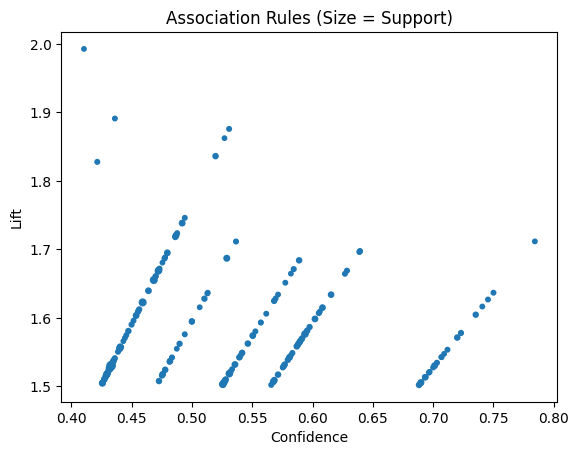

In [68]:
import matplotlib.pyplot as plt
plt.figure()

# Use support as size of points
plt.scatter(
    filtered_rules['confidence'], 
    filtered_rules['lift'], 
    s=filtered_rules['support'] * 1000
)

plt.xlabel('Confidence')
plt.ylabel('Lift')
plt.title('Association Rules (Size = Support)')

plt.show()

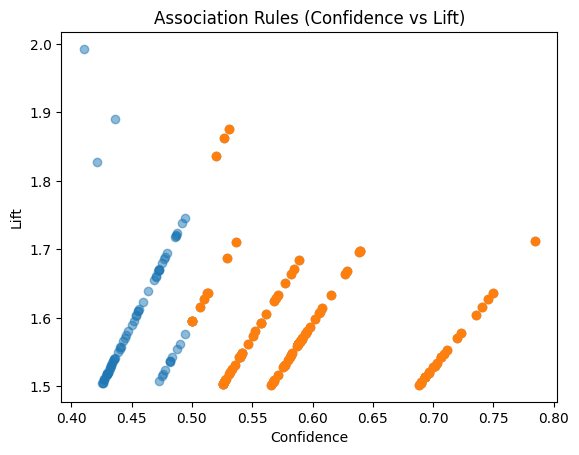

In [69]:
import matplotlib.pyplot as plt

plt.figure()

# Plot all rules (lighter look using alpha)
plt.scatter(
    filtered_rules['confidence'],
    filtered_rules['lift'],
    alpha=0.5
)

# Define strong rules
strong_rules = filtered_rules[
    (filtered_rules['confidence'] >= 0.5) &
    (filtered_rules['lift'] >= 1.5)
]

# Plot strong rules separately (same style, but clearer due to fewer points)
plt.scatter(
    strong_rules['confidence'],
    strong_rules['lift']
)

plt.xlabel('Confidence')
plt.ylabel('Lift')
plt.title('Association Rules (Confidence vs Lift)')

plt.show()